# Wind capacity factor composites

In [1]:
import xarray as xr
import pandas as pd
import numpy as np

import string
letters = list(string.ascii_lowercase)

import matplotlib.pyplot as plt

In [2]:
%cd /g/data/w42/dr6273/work/hot-cloudy/

/g/data/w42/dr6273/work/hot-cloudy


In [3]:
events = pd.read_csv(
    "hot_cloudy_2015_2024/event_dates_csi0p5_thourly90_counts.csv",
    parse_dates=True,
    index_col=0
)

In [4]:
nulls = pd.read_csv(
    "hot_cloudy_2015_2024/null_event_dates_csi0p5_thourly90_nhours7.csv",
    parse_dates=True,
    index_col=0
)

In [5]:
def get_yearly_wind(year):
    """
    Return array of wind speed for a desired year

    year: int
    """
    wind_path = "/scratch/w42/dr6273/BARRA-C2/derived/wind_speed/w100m/"
    return xr.open_zarr(
            wind_path+"w100m_BARRA-C2_20min_"+str(year)+".zarr",
            consolidated=True
        )["w100m"]

In [6]:
def get_date_wind(date):
    """
    Return array of wind speed for a single date, 1000-1600 AEST

    date: pandas Timestamp
    """
    # Open zarr store for desired year
    year = date.year
    wind = get_yearly_wind(year)

    # Select 0000-0600 UTC for date (corresponds to 1000-1600 AEST)
    end = date + pd.DateOffset(hour=6, minute=45)
    wind = wind.sel(time=slice(date, end))
    
    return wind

In [7]:
def get_all_dates_wind(dates):
    """
    Return concatenated array of wind speed for all dates

    dates: pandas DateTimeIndex
    """
    da_list = []
    for date in dates:
        wind = get_date_wind(date)
        da_list.append(wind)
    return xr.concat(da_list, dim="time")

In [8]:
def capacity_factor(W):
    """
    Computes capacity factor from wind speed data.
    
    W: wind speed (m/s)
    """
    W_0 = 3.5 # cut-in speed (m/s)
    W_r = 13 # rated speed
    W_1 = 25 # cut-out speed (m/s)
    
    # Cubic
    c_f = (W ** 3 - W_0 ** 3) / (W_r ** 3 - W_0 ** 3)
    c_f = c_f.where(W >= W_0, 0) # Set values below cut-in to zero
    c_f = c_f.where(W < W_r, 1) # Set values above rated speed to 1
    c_f = c_f.where(W < W_1, 0) # Set values above cut-off to zero
    c_f = c_f.where(W.notnull(), np.nan) # Ensure NaNs are retained
    
    return c_f

### Process for all regions

In [9]:
regions = np.unique(events["region"])

In [10]:
regions[[1,2,4,5]]

array(['GADE', 'GBRI', 'GMEL', 'GSYD'], dtype=object)

In [11]:
# If we need to compute the composites
compute = False

In [12]:
composite_data = {}
for region in regions[[1,2,4,5]]:
    composite_data[region] = {}

    if compute:
        # Event/null event days for region
        r_events = events[events["region"] == region]
        r_nulls = nulls[nulls["region"] == region]
    
        # Wind speed data
        r_wind_events = get_all_dates_wind(r_events.index)
        r_wind_nulls = get_all_dates_wind(r_nulls.index)
    
        # Capacity factors
        r_cf_events = capacity_factor(r_wind_events)
        r_cf_nulls = capacity_factor(r_wind_nulls)

        # Time-mean
        r_cf_events = r_cf_events.mean("time")
        r_cf_nulls = r_cf_nulls.mean("time")

        # Write to file
        r_cf_events.to_netcdf(
            "hot_cloudy_2015_2024/wind_capacity_factor_composite_events_"+region+".nc"
        )
        r_cf_nulls.to_netcdf(
            "hot_cloudy_2015_2024/wind_capacity_factor_composite_null_events_"+region+".nc"
        )

    # Read in composite data
    composite_data[region]["events"] = xr.open_mfdataset(
        "hot_cloudy_2015_2024/wind_capacity_factor_composite_events_"+region+".nc"
    )["w100m"].compute()
    composite_data[region]["nulls"] = xr.open_mfdataset(
        "hot_cloudy_2015_2024/wind_capacity_factor_composite_null_events_"+region+".nc"
    )["w100m"].compute()

In [13]:
import cartopy.crs as ccrs
import cartopy
cartopy.config['pre_existing_data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'
cartopy.config['data_dir'] = '/g/data/w42/dr6273/work/data/cartopy-data/'

In [ ]:
# fig, ax = plt.subplots(4, 3, figsize=(7, 9), subplot_kw={"projection": ccrs.PlateCarree()})

# for i, r in enumerate(regions[[1,2,4,5]]):
    
#     p = composite_data[r]["events"].plot(ax=ax[i,0], vmin=0, vmax=1, add_colorbar=False)
#     ax[i,0].set_title(r+" events", fontsize=9)
    
#     composite_data[r]["nulls"].plot(ax=ax[i,1], vmin=0, vmax=1, add_colorbar=False)
#     ax[i,1].set_title(r+" null events", fontsize=9)

#     diff = composite_data[r]["events"] - composite_data[r]["nulls"]
#     p_diff = diff.plot(ax=ax[i,2], vmin=-0.3, vmax=0.3, cmap="RdBu", add_colorbar=False)
#     ax[i,2].set_title(r+" difference", fontsize=9)

# for a in ax.flatten():
#     a.coastlines(lw=.2)
#     a.set_xlabel("")
#     a.set_xticklabels([])
#     a.set_ylabel("")
#     a.set_yticklabels([])

# plt.subplots_adjust(hspace=0.03)

# cax1 = fig.add_axes([0.15, 0.1, 0.27, 0.01])
# cbar1 = fig.colorbar(p, cax=cax1, ticks=np.arange(0, 1.01, 0.2), orientation="horizontal")
# cbar1.ax.set_xlabel(r"Capacity factor [-]", fontsize=9)

# cax2 = fig.add_axes([0.62, 0.1, 0.27, 0.01])
# cbar2 = fig.colorbar(p_diff, cax=cax2, ticks=np.arange(-0.3, 0.31, 0.15), orientation="horizontal")
# cbar2.ax.set_xlabel(r"Capacity factor difference [-]", fontsize=9)

# plt.savefig("figs/wind_capacity_factor_composites.png", format="png", dpi=200)

#### Add solar composite data

In [15]:
solar_composite_data = {}
for region in regions[[1,2,4,5]]:
    solar_composite_data[region] = {}
    
    # Read in composite data
    solar_composite_data[region]["events"] = xr.open_mfdataset(
        "hot_cloudy_2015_2024/solar_composite_events_"+region+".nc"
    ).surface_global_irradiance.compute()
    
    solar_composite_data[region]["nulls"] = xr.open_mfdataset(
        "hot_cloudy_2015_2024/solar_composite_null_events_"+region+".nc"
    ).surface_global_irradiance.compute()

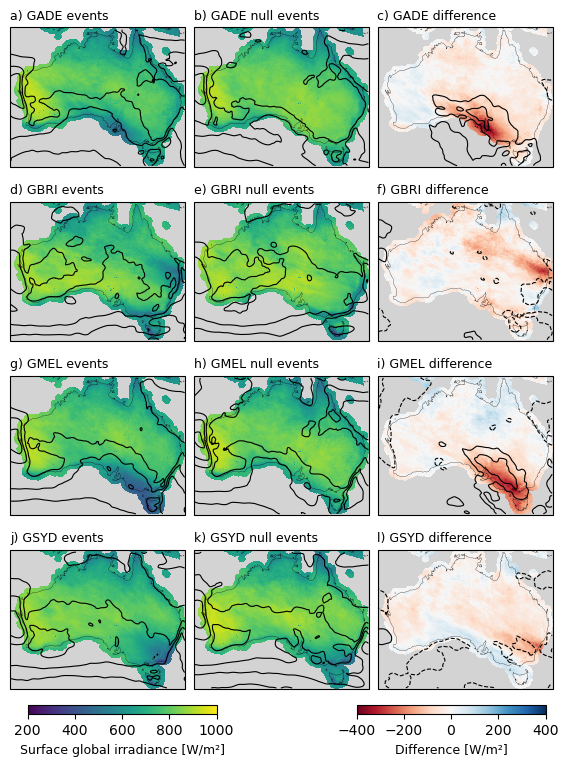

In [70]:
fig, ax = plt.subplots(4, 3,figsize=(7, 9), subplot_kw={"projection": ccrs.PlateCarree()})

cf_levels = np.arange(0, 1.01, 0.2)

plot_count = 0
for i, r in enumerate(regions[[1,2,4,5]][:]):
    
    p = solar_composite_data[r]["events"].plot(ax=ax[i,0], vmin=200, vmax=1000, add_colorbar=False)

    cf_smooth = (
        composite_data[r]["events"].rolling(lat=30, lon=30, center=True)
          .mean()
    )
    cs = cf_smooth.plot.contour(ax=ax[i,0], levels=cf_levels, colors="k", linewidths=0.8)
    
    # ax[i,0].clabel(cs, inline=True, fontsize=9) # Add labels
    ax[i,0].set_title("")
    ax[i,0].set_title(letters[plot_count]+") "+r+" events", fontsize=9, loc="left")
    plot_count += 1
    
    solar_composite_data[r]["nulls"].plot(ax=ax[i,1], vmin=200, vmax=1000, add_colorbar=False)

    cf_smooth = (
        composite_data[r]["nulls"].rolling(lat=30, lon=30, center=True)
          .mean()
    )
    cs = cf_smooth.plot.contour(ax=ax[i,1], levels=cf_levels, colors="k", linewidths=0.8)
    
    # ax[i,1].clabel(cs, inline=True, fontsize=9) # Add labels
    ax[i,1].set_title("")
    ax[i,1].set_title(letters[plot_count]+") "+r+" null events", fontsize=9, loc="left")
    plot_count += 1

    diff = solar_composite_data[r]["events"] - solar_composite_data[r]["nulls"]
    p_diff = diff.plot(ax=ax[i,2], vmin=-400, vmax=400, cmap="RdBu", add_colorbar=False)

    diff_s = composite_data[r]["events"] - composite_data[r]["nulls"]
    cf_smooth = (
        diff_s.rolling(lat=30, lon=30, center=True)
          .mean()
    )
    levels = np.round(np.arange(-0.3, 0.31, 0.1), 1)
    levels = [i for i in levels if i != 0]
    p_diff_s = cf_smooth.plot.contour(
        ax=ax[i,2],
        levels=levels, colors="k", linewidths=0.8
    )
    # ax[i,2].clabel(p_diff_s, inline=True, fontsize=9) # Add labels
    ax[i,2].set_title("")
    ax[i,2].set_title(letters[plot_count]+") "+r+" difference", fontsize=9, loc="left")
    plot_count += 1

for a in ax.flatten():
    a.add_feature(cartopy.feature.OCEAN, facecolor="lightgray", zorder=0)
    a.coastlines(lw=.2)
    a.set_xlabel("")
    a.set_xticklabels([])
    a.set_ylabel("")
    a.set_yticklabels([])
    a.set_extent([111, 154.5, -10, -42.5])

plt.subplots_adjust(hspace=0.03)

cax1 = fig.add_axes([0.15, 0.1, 0.27, 0.01])
cbar1 = fig.colorbar(p, cax=cax1, ticks=np.arange(200, 1001, 200), orientation="horizontal")
cbar1.ax.set_xlabel(r"Surface global irradiance [W/m²]", fontsize=9)

cax2 = fig.add_axes([0.62, 0.1, 0.27, 0.01])
cbar2 = fig.colorbar(p_diff, cax=cax2, ticks=np.arange(-400, 401, 200), orientation="horizontal")
cbar2.ax.set_xlabel(r"Difference [W/m²]", fontsize=9)

plt.subplots_adjust(hspace=0.02, wspace=0.05)

# plt.savefig("figs/energy_resource_composites.png", format="png", dpi=200)